In [28]:
import pandas as pd
import numpy as np 


In [29]:
df = pd.read_csv('data/credit_dataset.csv')
print(df.head())
print(df.info())

   Age  Gender  Income            Education Marital Status  \
0   25  Female   50000    Bachelor's Degree         Single   
1   30    Male  100000      Master's Degree        Married   
2   35  Female   75000            Doctorate        Married   
3   40    Male  125000  High School Diploma         Single   
4   45  Female  100000    Bachelor's Degree        Married   

   Number of Children Home Ownership Credit Score  
0                   0         Rented         High  
1                   2          Owned         High  
2                   1          Owned         High  
3                   0          Owned         High  
4                   3          Owned         High  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 164 non-null    int64 
 1   Gender              164 non-null    object
 2   Income        

In [30]:
print(df.isna().any())

Age                   False
Gender                False
Income                False
Education             False
Marital Status        False
Number of Children    False
Home Ownership        False
Credit Score          False
dtype: bool


In [31]:
print(df.describe().T)

                    count          mean           std      min       25%  \
Age                 164.0     37.975610      8.477289     25.0     30.75   
Income              164.0  83765.243902  32457.306728  25000.0  57500.00   
Number of Children  164.0      0.652439      0.883346      0.0      0.00   

                        50%       75%       max  
Age                    37.0      45.0      53.0  
Income              83750.0  105000.0  162500.0  
Number of Children      0.0       1.0       3.0  


In [32]:
object_columns = df.select_dtypes(include='object').columns.to_list()
for col in object_columns:
    print(f'{col} : unique values: {df[col].unique()}')

Gender : unique values: ['Female' 'Male']
Education : unique values: ["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
Marital Status : unique values: ['Single' 'Married']
Home Ownership : unique values: ['Rented' 'Owned']
Credit Score : unique values: ['High' 'Average' 'Low']


У меня 5 категориальных признаков, которые нужно закодировать. Для Credit Score и Education лучше всего подойдет OrdinalEncoder, т.к прослеживается четкий порядок приоритетности. Для остальных подойдет OneHotEncoder, т.к какого-то порядка не существует.

In [33]:
ordinals = ['Education', 'Credit Score']
one_hots = ['Gender', 'Marital Status', 'Home Ownership']

In [34]:
from sklearn.preprocessing import OrdinalEncoder 
ordinal_encoder = OrdinalEncoder(
    categories=[[
        "High School Diploma",
        "Associate's Degree",
        "Bachelor's Degree",
        "Master's Degree",
        "Doctorate"
    ],
    [
        "Low",
        "Average",
        "High",
    ]]
)
df[ordinals] = ordinal_encoder.fit_transform(df[ordinals])
df = pd.get_dummies(df, columns=one_hots, drop_first=True, dtype=int)

Text(0.5, 1.0, 'Correlation Matrix')

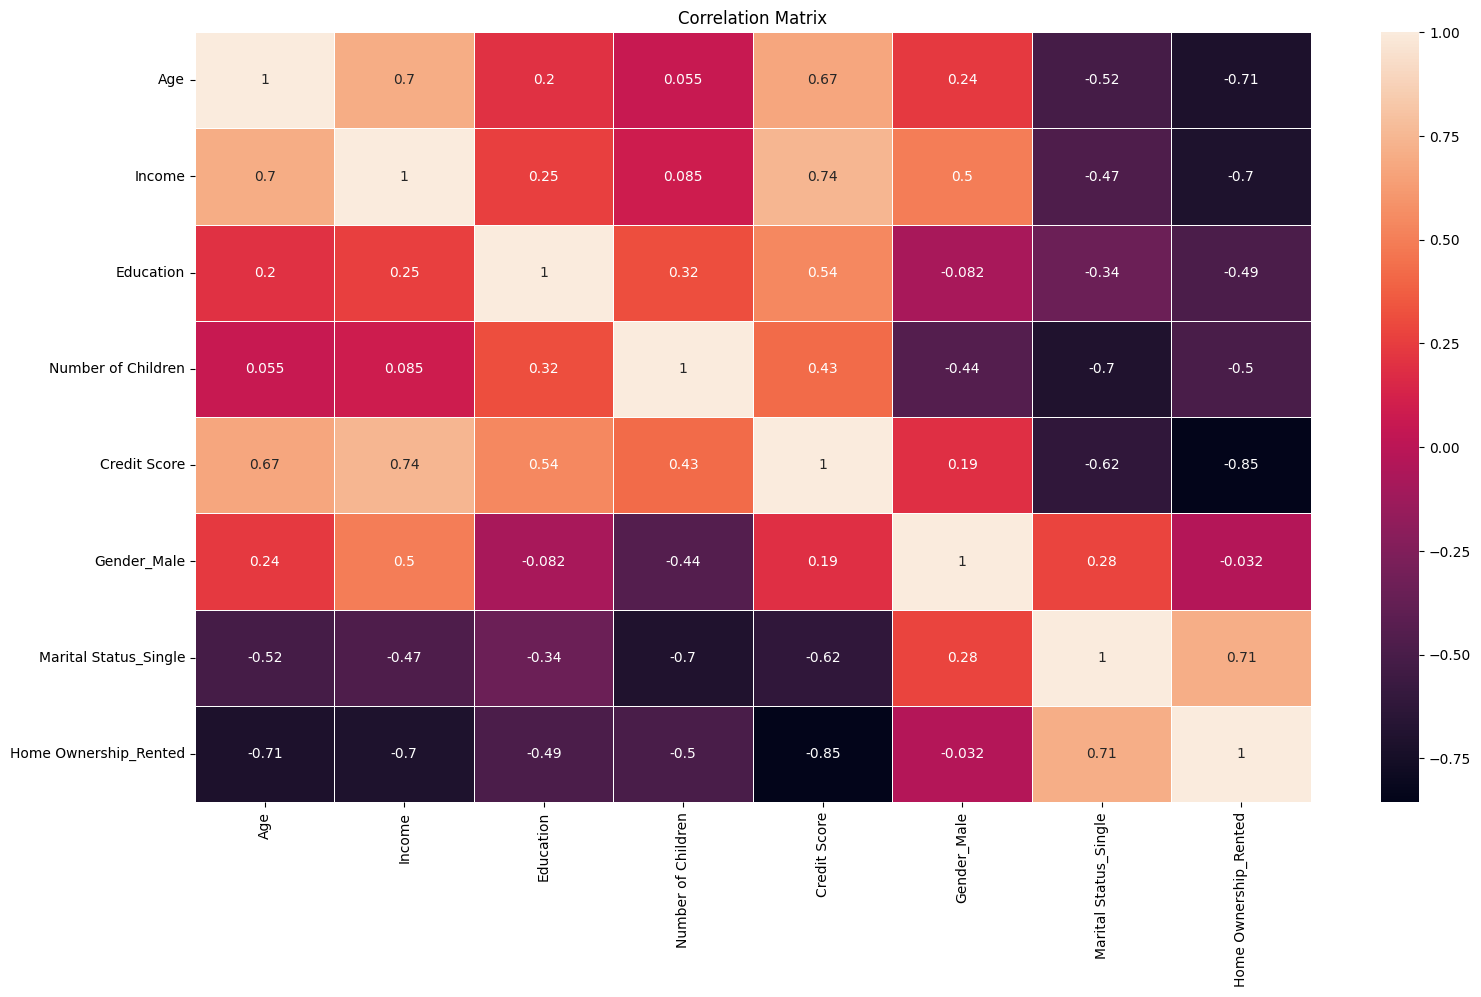

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))
sns.heatmap(df.corr(), annot=True, linewidths=0.5)
plt.title('Correlation Matrix')

Как видно из графика, присутствует дисбаланс классов. 'High' - значительно выше. Я буду бороться с этим дисбалансом с помощью SMOTE, буду искуственно добавлять данные. После SMOTE я приведу признаки к одному мастшабу через StandartScaler, чтобы признаки с большими значениями не доминировали.

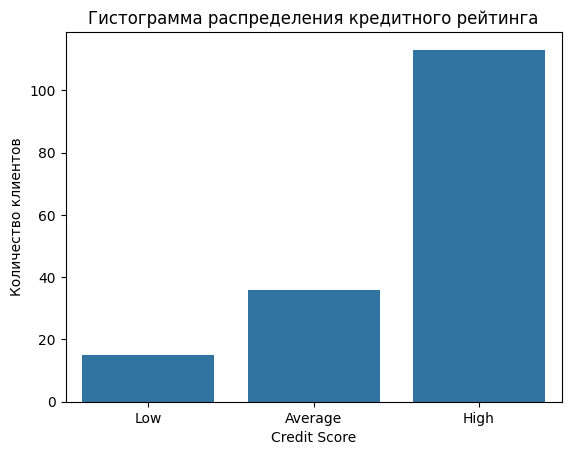

In [36]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.countplot(x='Credit Score', data=df)
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Average', 'High'])
plt.ylabel('Количество клиентов')
plt.title('Гистограмма распределения кредитного рейтинга') 
plt.show()


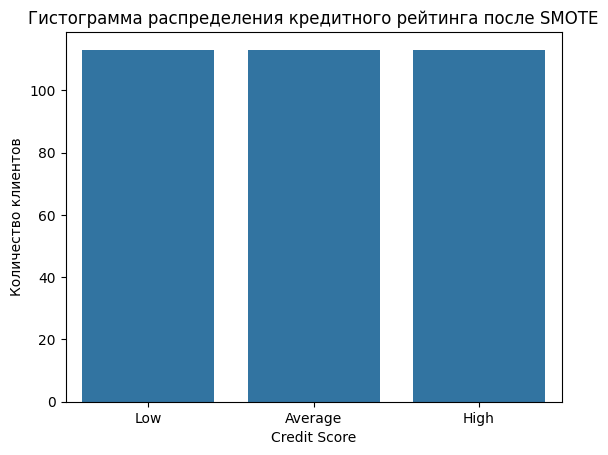

In [37]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Credit Score'])
y = df['Credit Score'] 

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y) # Применяем SMOTE для балансировки классов

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_smote) # Масштабируем признаки после применения SMOTE

sns.countplot(x=y_smote)
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Average', 'High'])
plt.ylabel('Количество клиентов')
plt.title('Гистограмма распределения кредитного рейтинга после SMOTE')
plt.show()


Данных достаточно мало, по этому логичным шагом будет применить k-fold cross validation. Я буду обучать сразу несколько моделей: RandomForest, LogisticRegression, XGBClassifier. А в конце попробуй использовать KNN.

In [38]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_ovr"] # Метрики, которые я буду использовать. roc_auc_ovr - это AUC для многоклассовой классификации, который использует стратегию "Один против всех".

forest_model = RandomForestClassifier(random_state=67)
logistic_model = LogisticRegression(random_state=67)
xgboost_model = XGBClassifier(random_state=67)

kf = KFold(n_splits=5, shuffle=True, random_state=67)

def eval_model(model):
    cv_scores = cross_validate(model, X_scaled, y_smote, cv=kf, scoring=scoring)
    for metric in scoring:
        current_score = cv_scores[f'test_{metric}'].mean()
        print(f"{model.__class__.__name__}: {metric} - {current_score:.4f}")
    print('---')

eval_model(forest_model)
eval_model(logistic_model)
eval_model(xgboost_model)

RandomForestClassifier: accuracy - 0.9971
RandomForestClassifier: precision_macro - 0.9956
RandomForestClassifier: recall_macro - 0.9968
RandomForestClassifier: f1_macro - 0.9961
RandomForestClassifier: roc_auc_ovr - 0.9977
---
LogisticRegression: accuracy - 0.9705
LogisticRegression: precision_macro - 0.9700
LogisticRegression: recall_macro - 0.9697
LogisticRegression: f1_macro - 0.9692
LogisticRegression: roc_auc_ovr - 0.9971
---
XGBClassifier: accuracy - 0.9882
XGBClassifier: precision_macro - 0.9891
XGBClassifier: recall_macro - 0.9854
XGBClassifier: f1_macro - 0.9870
XGBClassifier: roc_auc_ovr - 0.9963
---


RandomForest показал наилучшую оценку по всем метрикам. Теперь попробуем использовать алгоритм KNN, для него я не буду делить датасет по фолдам, а буду использовать датасет после SMOTE и Scaled, разделенный на train/test.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_smote, test_size=0.3, random_state=67)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        36
         1.0       1.00      1.00      1.00        40
         2.0       1.00      1.00      1.00        26

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
weighted avg       1.00      1.00      1.00       102


Confusion matrix:
[[36  0  0]
 [ 0 40  0]
 [ 0  0 26]]


С разделением на train/test по метрикам получается все идеально. Теперь поробуем использовать cross_validation для KNN.

In [40]:
from sklearn.model_selection import cross_validate
knn_model = KNeighborsClassifier()
cv_results = cross_validate(knn_model, X_scaled, y_smote, cv=20, scoring=scoring) 
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"KNN: {metric} -  {scores.mean():.4f}")


KNN: accuracy -  0.9824
KNN: precision_macro -  0.9859
KNN: recall_macro -  0.9817
KNN: f1_macro -  0.9817
KNN: roc_auc_ovr -  0.9930
